# Grayscale Image Filtering Basics
__Author__: Masa Prodanovic
__Last update__: Dec 2024


In [1]:
# Import libraries

#pip install dpm_tools
#pip install scikit-image

# Anisotropic diffision filter is found in MedPy 
# https://pypi.org/project/MedPy/
#pip install medpy

!pip install --user --use-pep517 medpy

try:
    import dpm_tools
    assert dpm_tools.__version__ >= "0.0.4"
except ModuleNotFoundError:
    !pip install --user -r ./requirements.txt
except AssertionError:
    !pip install --upgrade dpm_tools --user


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import skimage
from skimage import io, img_as_float, img_as_ubyte, img_as_int

import skimage.filters as sf
import skimage.morphology as sm
import skimage.transform as st

import dpm_tools
from dpm_tools.io import download_file
from dpm_tools.metrics import histogram_statistics as hist_stats

from medpy.filter.smoothing import anisotropic_diffusion

from skimage import exposure

from scipy import ndimage # used convolve function


C:\Users\masha\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


# Examples
## Download and/or read in a 2D sandstone image from Digital Rocks Portal and  plot/compare image stats

I found a nice set of 2D sandstone slices at two different resolutions in Project 211. These are X-ray microtomography images.

In [2]:
#image location, this is higher resolution image (see project for more details), if it needs to be downloaded
#file_url1 = "https://www.digitalrocksportal.org/projects/211/images/126114/download/";
filename1 = "../data/Project211_sandstone_slice_0801hr.png"
# download_file(file_url1, filename1) #uncomment if you need to download again

# image location, this is a lower resolution image (see project)
#file_url2 = "https://www.digitalrocksportal.org/projects/211/images/126113/download/"
filename2 = "../data/Project211_sandstone_slice_0801lr.png"
# download_file(file_url1, filename1) #uncomment if you need to download again


__These images are the same sample imaged at higher and lower resolutions.__
__We read images, and display the entire images as well as smaller subsets where we can appreciate the differences.__

__Color shown is the default colormap of matplotlib. This is NOT true color, x-ray images have single values, but I use it instead of
gray as differences on screen tend to be better visible than in gray__

Text(0.5, 1.0, 'lower res')

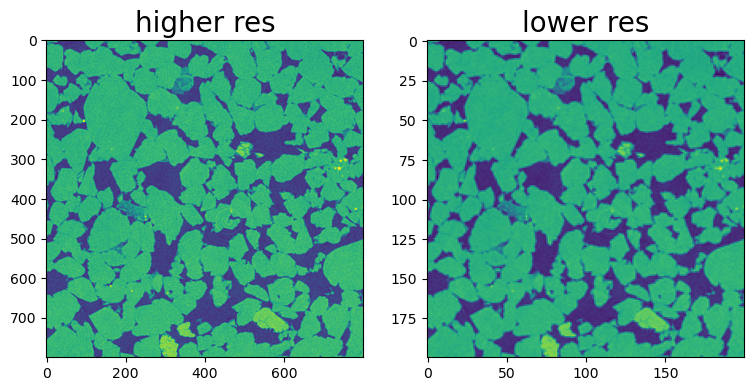

In [3]:
img_hr = io.imread(filename1) # read the file
img_hr = img_hr[:,:,0] #use only one channel of the three channels available

img_lr = io.imread(filename2) # read the file
img_lr = img_lr[:,:,0] #use only one channel of the three channels available

f = plt.figure(figsize=(9, 18))
f.add_subplot(121)
plt.imshow(img_hr) # if the image has three channels, default - and fake - color will appear when using imshow. Color scheme can easily be changed.
plt.title('higher res',fontsize=20)

f.add_subplot(122)
plt.imshow(img_lr) # if the image has three channels, default - and fake - color will appear when using imshow
plt.title('lower res',fontsize=20)




Text(0.5, 1.0, 'zoom in - lower res')

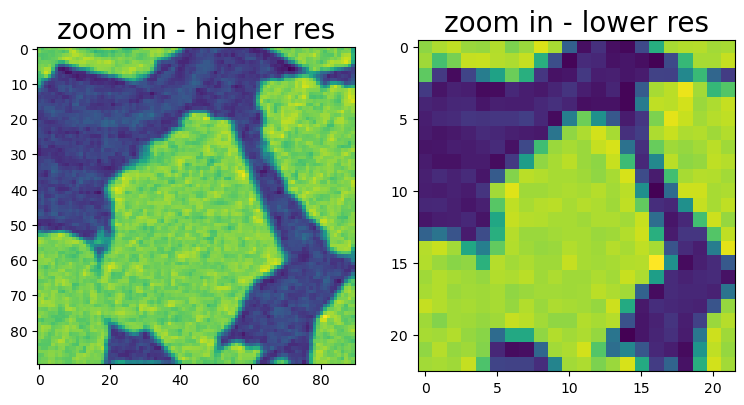

In [14]:
# Zoom into a subset
# location and length of an image subset in x, y directions
locx = 470
lenx = 90
locy = 440
leny = 90

f = plt.figure(figsize=(9, 18))
f.add_subplot(121)
plt.imshow(img_hr[locx:(locx+lenx),locy:(locy+leny)]) # add cmap='gray' to imshow function to change colormap to gray.
plt.title('zoom in - higher res',fontsize=20)

f.add_subplot(122)
# note that // is floor division (so we get integers as a result)
plt.imshow(img_lr[locx//4:(locx+lenx)//4,locy//4:(locy+leny)//4]) 
plt.title('zoom in - lower res',fontsize=20)

__Now look into the basic statistics of the images. Do you think we will observe a difference in the image histograms and what will the difference be?__

###  Correlation as a way to register images or match templates

We first try a very basic correlation. It does not work well - see below.



Image (ndarray) shape (800, 800)

Image data type float64

Image values min: 571.3738869665522 max: 2912.719292579771 mean: 2295.5087067570416


()

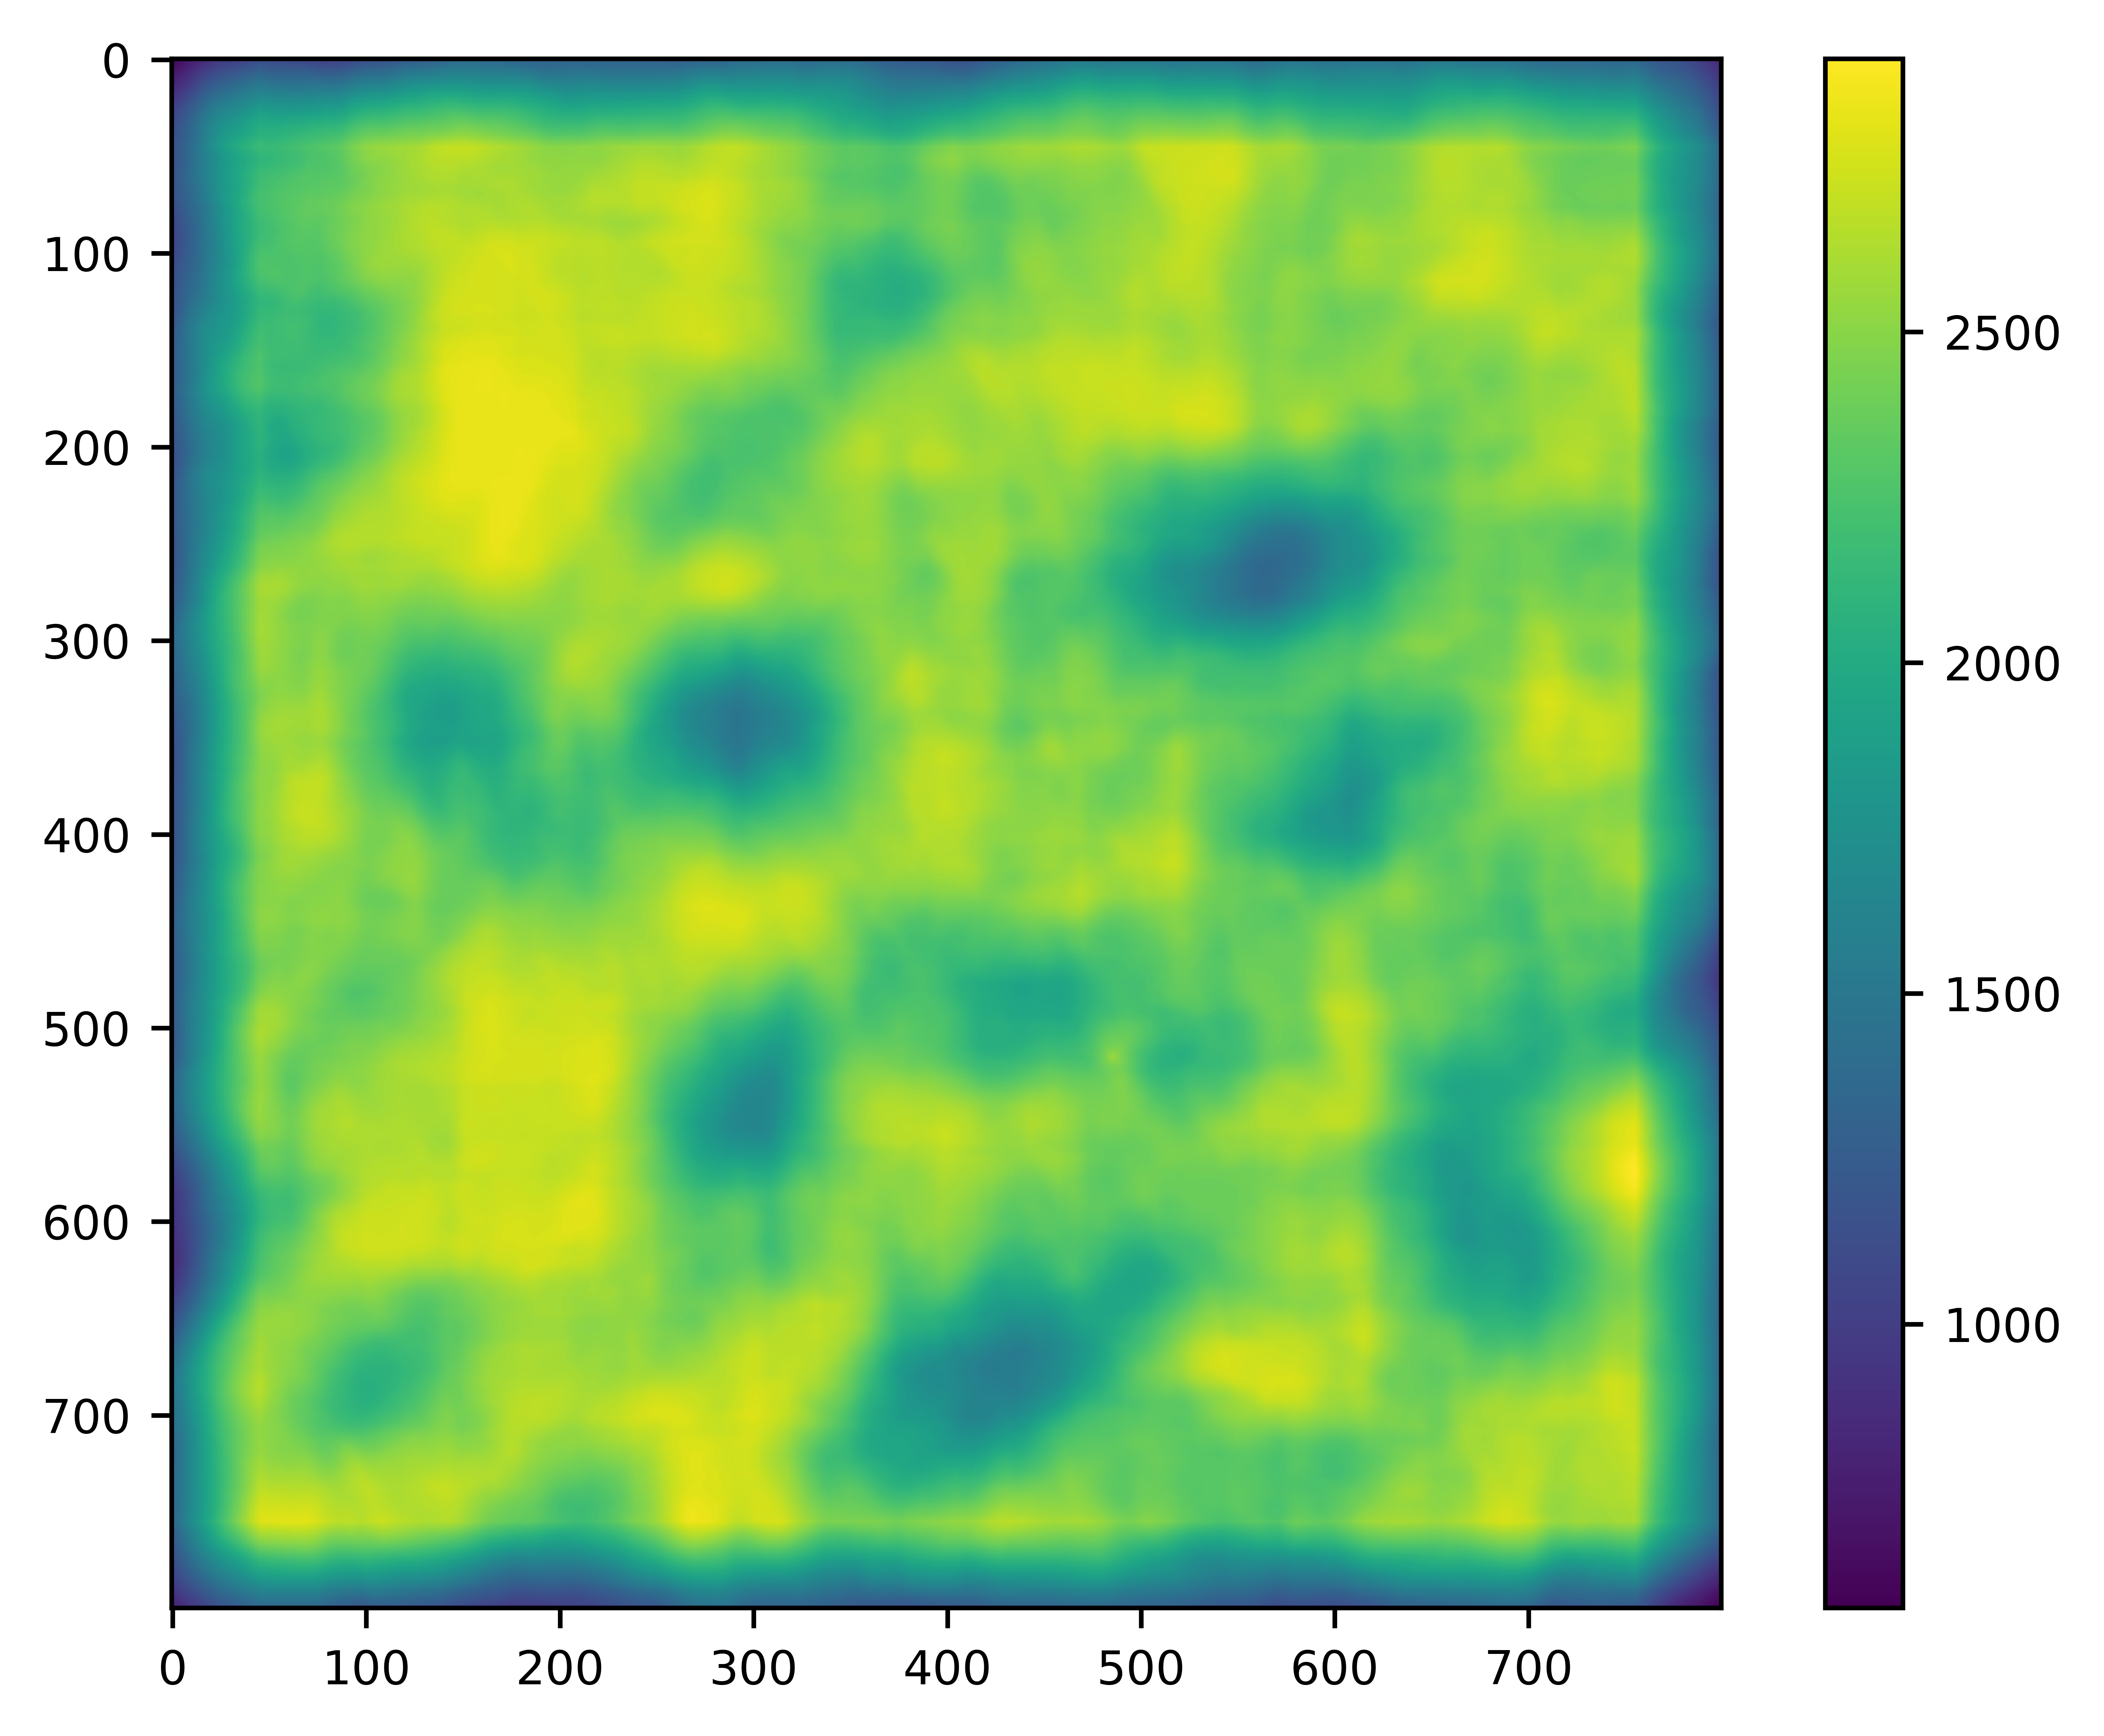

In [ ]:
# This is a simple correlation, to see if it works.
# I expect the sub image when overlapped its original version to have a high number
# resulting from correlating/convolving it.
#
# It fails to find the match pretty misearably, I am thinking because:
# - correlation is done using the original and fairly noisy image with a wide range 
#   of values
# - the small pore structure in subset is likely found in multiple locations in the image

import skimage as si
from scipy import ndimage

#Recreate subset of an image
# location and length of an image subset in x, y directions
locx = 500
lenx = 50
locy = 440
leny = 50

# a slightly larger version
locx = 470
lenx = 90
locy = 440
leny = 90


f.add_subplot(223)
img_sub1 = si.img_as_float(np.copy(img_hr[locx:(locx+lenx),locy:(locy+leny)]))

img_correlate= ndimage.correlate(si.img_as_float(img_hr[:,:]), img_sub1,mode='constant',cval=0.0)
plt.figure(dpi=1200)
plt.imshow(img_correlate)
plt.colorbar()

hist_stats(img_correlate, plot_histogram=False)

The template matching from skimage works really well for this test case: # https://scikit-image.org/docs/0.18.x/auto_examples/features_detection/plot_template.html#sphx-glr-auto-examples-features-detection-plot-template-py

I did not look into the details but it likely uses FT.

There is also a phase correlation that could be explored:
https://scikit-image.org/docs/0.13.x/auto_examples/transform/plot_register_translation.html

It is quite likely these functions do not work fast with larger 3D images, but such is life.


In [75]:
# this example is modified from 
# https://scikit-image.org/docs/0.18.x/auto_examples/features_detection/plot_template.html#sphx-glr-auto-examples-features-detection-plot-template-py
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template

def match_template_test(image,coin):
    #image = data.coins()
    #coin = image[170:220, 75:130]

    result = match_template(image, coin)
    ij = np.unravel_index(np.argmax(result), result.shape)
    x, y = ij[::-1]

    fig = plt.figure(figsize=(12, 5))
    ax1 = plt.subplot(1, 3, 1)
    ax2 = plt.subplot(1, 3, 2)
    ax3 = plt.subplot(1, 3, 3, sharex=ax2, sharey=ax2)

    ax1.imshow(coin, cmap=plt.cm.gray)
    ax1.set_axis_off()
    ax1.set_title('template')

    ax2.imshow(image, cmap=plt.cm.gray)
    ax2.set_axis_off()
    ax2.set_title('image')
    # highlight matched region
    hcoin, wcoin = coin.shape
    rect = plt.Rectangle((x, y), wcoin, hcoin, edgecolor='r', facecolor='none')
    ax2.add_patch(rect)

    ax3.imshow(result)
    ax3.set_axis_off()
    ax3.set_title('`match_template`\nresult')
    # highlight matched region
    ax3.autoscale(False)
    ax3.plot(x, y, 'o', markeredgecolor='r', markerfacecolor='none', markersize=10)

    plt.show()
    

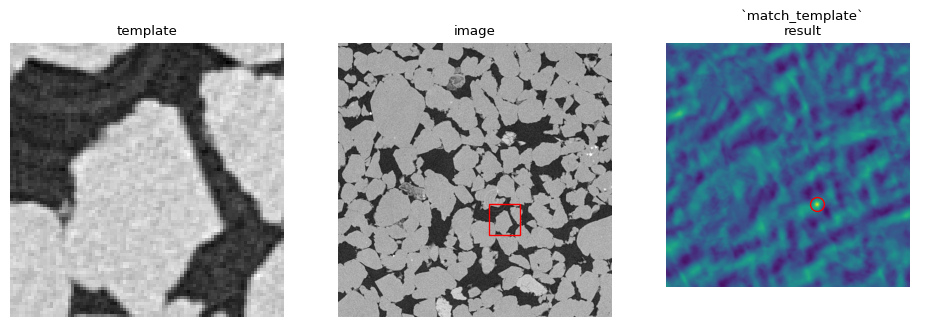

In [77]:
match_template_test(si.img_as_float(img_hr[:,:]),si.img_as_float(img_sub1[:,:]))     

## Improving contrast by histogram manipulation

Often, the image is so-called "low contrast" which refers to the values of the image having a small range. The example is shown for the fracture above. Note that the histogram of the sandstone slice is already spread over the entire range of possible values and it does not need manipulation like this. Sometimes, the fix is an easy "stretch" of the histogram (linear) to enhance contrast. Nonlinear manipulation attempts to create a uniform distribution of values. The following code, borrowed from skimage examples compares different manipulations of histogram.

References:
- https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_equalize.html
- Ch. 3. in "Digital Image Processing"

In [75]:
#This code is borrowed from the above scikit link 

#matplotlib.rcParams['font.size'] = 8

def plot_img_and_hist(image, axes, bins=256):
    """Plot an image along with its histogram and cumulative histogram."""
    image = img_as_float(image)
    ax_img, ax_hist = axes
    ax_cdf = ax_hist.twinx()

    # Display image
    ax_img.imshow(image, cmap=plt.cm.gray)
    ax_img.set_axis_off()

    # Display histogram
    ax_hist.hist(image.ravel(), bins=bins, histtype='step', color='black')
    ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax_hist.set_xlabel('Pixel intensity')
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])

    # Display cumulative distribution
    img_cdf, bins = exposure.cumulative_distribution(image, bins)
    ax_cdf.plot(bins, img_cdf, 'r')
    ax_cdf.set_yticks([])

    return ax_img, ax_hist, ax_cdf


def try_all_histogram_changes(img):
    
    # Contrast stretching
    p2, p98 = np.percentile(img, (2, 98))
    img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
    
    # Equalization
    img_eq = exposure.equalize_hist(img)
    
    # Adaptive Equalization
    img_adapteq = exposure.equalize_adapthist(img, clip_limit=0.03)
    
    # Display results
    fig = plt.figure(figsize=(8, 5))
    axes = np.zeros((2, 4), dtype=object)
    axes[0, 0] = fig.add_subplot(2, 4, 1)
    for i in range(1, 4):
        axes[0, i] = fig.add_subplot(2, 4, 1 + i, sharex=axes[0, 0], sharey=axes[0, 0])
    for i in range(0, 4):
        axes[1, i] = fig.add_subplot(2, 4, 5 + i)
    
    ax_img, ax_hist, ax_cdf = plot_img_and_hist(img, axes[:, 0])
    ax_img.set_title('Low contrast image')
    
    y_min, y_max = ax_hist.get_ylim()
    ax_hist.set_ylabel('Number of pixels')
    ax_hist.set_yticks(np.linspace(0, y_max, 5))
    
    ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_rescale, axes[:, 1])
    ax_img.set_title('Contrast stretching')
    
    ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_eq, axes[:, 2])
    ax_img.set_title('Histogram equalization')
    
    ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_adapteq, axes[:, 3])
    ax_img.set_title('Adaptive equalization')
    
    ax_cdf.set_ylabel('Fraction of total intensity')
    ax_cdf.set_yticks(np.linspace(0, 1, 5))
    
    # prevent overlap of y-axis labels
    fig.tight_layout()
    plt.show()

    return()

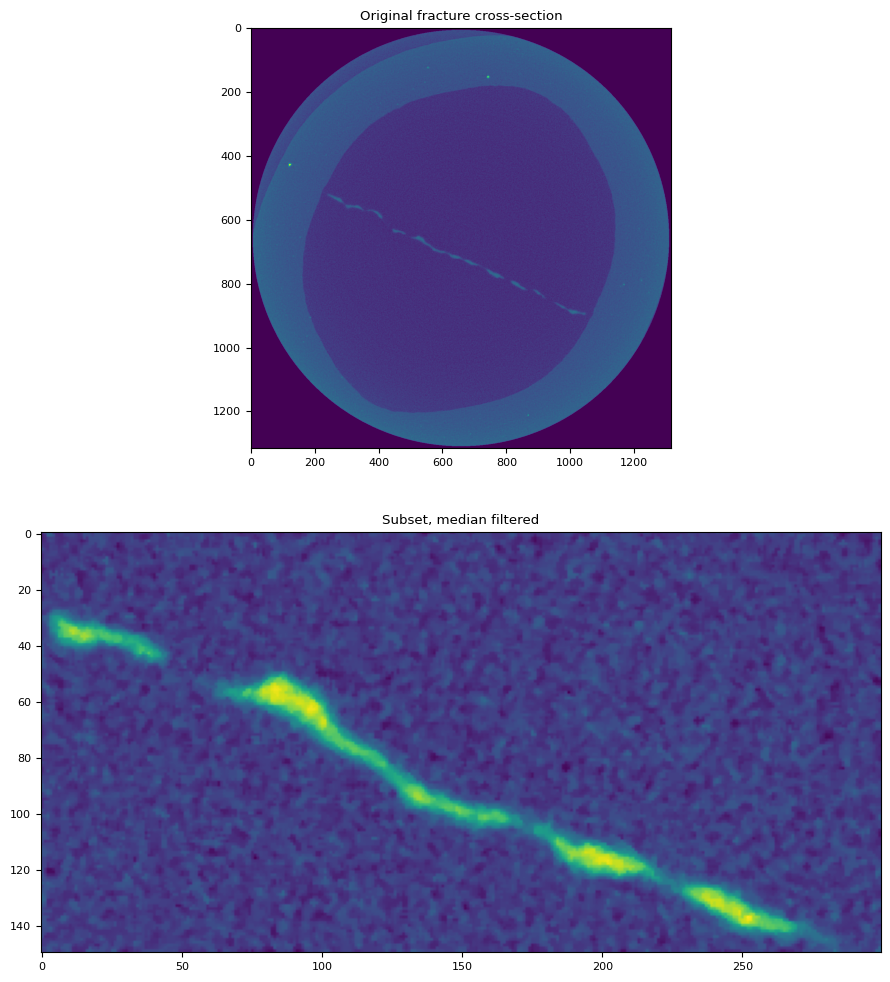

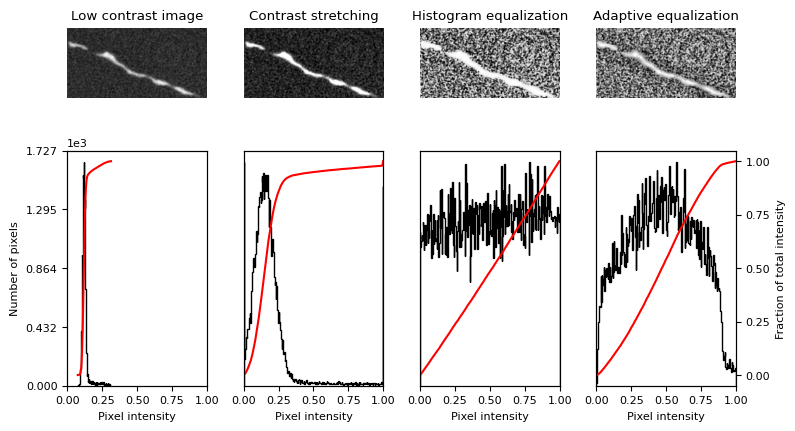

()

In [81]:
# Load an example image

import skimage.io as io

#Read a cropped slice through a fracture from Digital Rocks Portal
img_frac = io.imread('Project339_fracture_scan2_000130.tif')

f = plt.figure(figsize=(12, 12))
f.add_subplot(211)
#plt.imshow(img_frac,cmap='gray')
plt.imshow(img_frac)
plt.title('Original fracture cross-section')

locx = 600
lenx = 150
locy = 440
leny = 300

img = np.copy(img_frac[locx:(locx+lenx),locy:(locy+leny)])
img_med = sf.median(img,sm.square(3))

f.add_subplot(212)
#plt.imshow(img,cmap='gray')
plt.imshow(img_med)
plt.title('Subset, median filtered') # median filtering does not do much here

img_float = si.img_as_float(img_med)
try_all_histogram_changes(img_float) 

# Advanced: White tophat example FIND BETTER EXAMPLE

Grayscale erosion using a neighborhood or a structuring element surrounding a point means replacing the value at a point with the minimum of the points in its neighborhood.

Grayscale dilation is then defined as taking the maximum in a neighborhood of a point.

Opening = erosion followed by dilation.

Closing = dilation followed by erosion.


White top-hat transform is defined as the difference between the input image and its opening by some structuring element.
Black top-hat transform is defined as the difference between the input image and its opening by some structuring element.

The white top-hat transform returns an image, containing those "objects" or "elements" of an input image that:

    are "smaller" than the structuring element (i.e., places where the structuring element does not fit in), and
    are brighter than their surroundings.

The black top-hat returns an image, containing the "objects" or "elements" that:

    are "smaller" than the structuring element, and
    are darker than their surroundings.

The size, or width, of the elements that are extracted by the top-hat transforms can be controlled by the choice of the structuring element b. The bigger the latter, the larger the elements extracted.

Both top-hat transforms are images that contain only non-negative values at all pixels.

One of its most important uses in image segmentation is to adjust nonuniform lighting conditions on an image and provide a better threshold value for separating objects. 





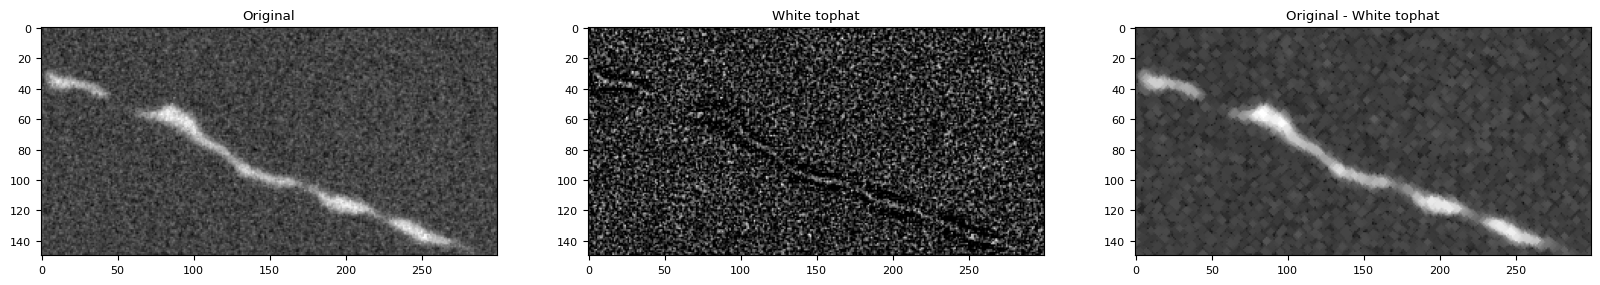

In [63]:
# This is not the best example for use of the top hat. Using it as a stand-in.

from skimage import morphology

def top_hat_filter_demo(image):
    selem =  morphology.disk(2)
    res = morphology.white_tophat(image, selem)

    fig, ax = plt.subplots(ncols=3, figsize=(20, 8))
    ax[0].set_title('Original')
    ax[0].imshow(image, cmap='gray')
    ax[1].set_title('White tophat')
    ax[1].imshow(res, cmap='gray')
    ax[2].set_title('Original - White tophat')
    ax[2].imshow(image - res, cmap='gray')

    plt.show()
    image_filtered = image - res
    return (image - res)

img_filtered = top_hat_filter_demo(img_float)